<a href="https://colab.research.google.com/github/madhankumarm2408-sketch/Future_ML_03/blob/main/Resume_Candidate_Screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.corpus import stopwords
from google.colab import files

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv('Resume.csv')

print(f'Dataset loaded: {df.shape[0]} resumes, {df.shape[1]} columns')
print(f'\nColumn names: {list(df.columns)}')
df.head(3)

Saving Resume.csv to Resume.csv
Dataset loaded: 2484 resumes, 4 columns

Column names: ['ID', 'Resume_str', 'Resume_html', 'Category']


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df.columns = [col.strip() for col in df.columns]  # remove accidental whitespace

print('Missing values per column:')
print(df.isnull().sum())
print()

print('Resume count by job category:')
print(df['Category'].value_counts())

Missing values per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Resume count by job category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


/tmp/ipykernel_3160/1040097.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')


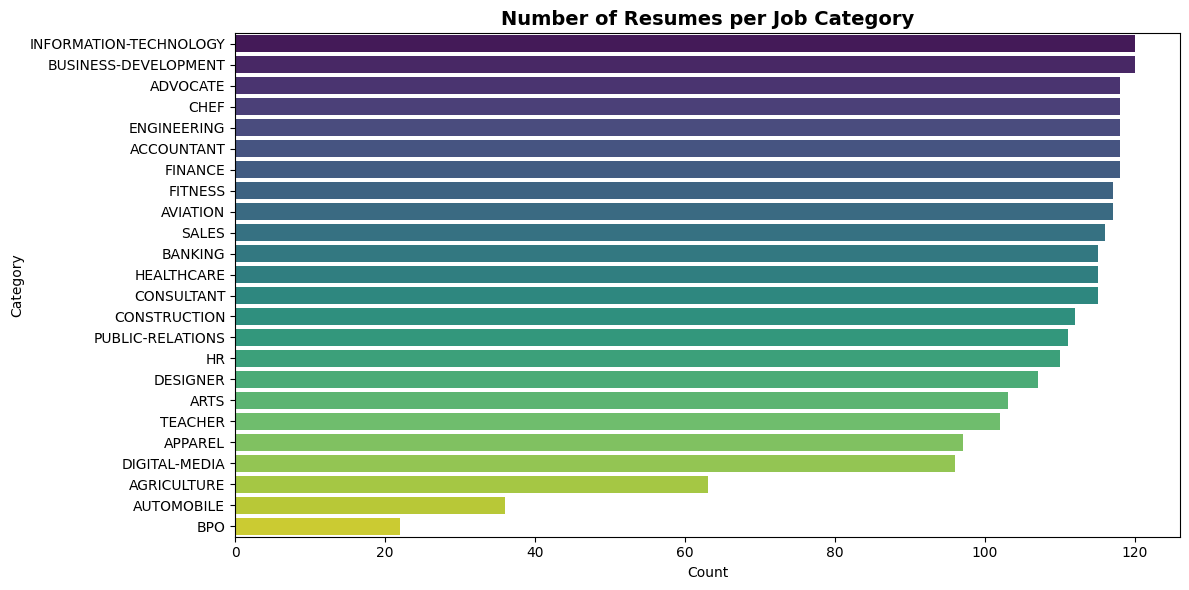

In [ ]:
plt.figure(figsize=(12, 6))
category_counts = df['Category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Number of Resumes per Job Category', fontsize=14, fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

In [ ]:
df = df.rename(columns={'Resume_str': 'Resume'})

In [ ]:
print('=== Sample Raw Resume Text ===')
print(df['Resume'].iloc[0][:1000], '...')

=== Sample Raw Resume Text ===
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies

In [ ]:
STOP_WORDS = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Cleans a piece of text for NLP processing.
    Returns a clean, lowercased string with noise removed.
    """
    if not isinstance(text, str):
        return ''

    text = text.lower()

    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    text = re.sub(r'\S+@\S+', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = text.split()
    tokens = [word for word in tokens if word not in STOP_WORDS and len(word) > 2]

    return ' '.join(tokens)

df['cleaned_resume'] = df['Resume'].apply(preprocess_text)

print(' Preprocessing complete!')
print('\nBefore:', df['Resume'].iloc[0][:200])
print('\nAfter: ', df['cleaned_resume'].iloc[0][:200])

 Preprocessing complete!

Before:          HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

After:  administrator marketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customer focused teams stri


In [ ]:
SKILL_KEYWORDS = [
    # Programming Languages
    'python', 'java', 'javascript', 'c++', 'r', 'sql', 'scala', 'go', 'ruby', 'php',
    'typescript', 'swift', 'kotlin', 'matlab',
    # ML / AI
    'machine learning', 'deep learning', 'neural network', 'nlp', 'computer vision',
    'tensorflow', 'pytorch', 'keras', 'scikit-learn', 'xgboost', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'opencv', 'huggingface', 'transformers', 'bert', 'gpt',
    # Data
    'data analysis', 'data science', 'data engineering', 'etl', 'spark', 'hadoop',
    'tableau', 'power bi', 'excel', 'sql', 'nosql', 'mongodb', 'postgresql',
    # Cloud & DevOps
    'aws', 'azure', 'gcp', 'docker', 'kubernetes', 'git', 'github', 'linux',
    'ci/cd', 'jenkins', 'terraform',
    # Web
    'react', 'angular', 'vue', 'node.js', 'django', 'flask', 'fastapi', 'html', 'css',
    # Soft Skills / General
    'communication', 'leadership', 'agile', 'scrum', 'project management',
    'problem solving', 'teamwork', 'research'
]

def extract_skills(text, skill_list=SKILL_KEYWORDS):

    text_lower = text.lower()
    return set(skill for skill in skill_list if skill in text_lower)

sample_skills = extract_skills(df['Resume'].iloc[0])
print(f'Skills found in resume #1 ({len(sample_skills)} skills):')
print(sorted(sample_skills))

Skills found in resume #1 (6 skills):
['aws', 'data analysis', 'go', 'leadership', 'r', 'swift']


In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words='english'
)
resume_vectors = tfidf.fit_transform(df['cleaned_resume'])

print(f'TF-IDF matrix shape: {resume_vectors.shape}')
print(f'   → {resume_vectors.shape[0]} resumes, each represented by {resume_vectors.shape[1]} features (words/phrases)')

TF-IDF matrix shape: (2484, 5000)
   → 2484 resumes, each represented by 5000 features (words/phrases)


In [ ]:
JOB_DESCRIPTION = """
We are looking for a Data Scientist with strong experience in Python and machine learning.
The ideal candidate should be proficient in scikit-learn, TensorFlow or PyTorch, and pandas.
Experience with SQL, data analysis, and data visualization using matplotlib or seaborn is required.
Knowledge of NLP and deep learning is a plus. The role requires excellent communication skills
and the ability to work in an agile team environment. Experience with cloud platforms like AWS
or GCP and version control using Git is expected.
"""

required_skills = extract_skills(JOB_DESCRIPTION)
print(f'Job requires {len(required_skills)} detected skills:')
print(sorted(required_skills))

Job requires 19 detected skills:
['agile', 'aws', 'communication', 'data analysis', 'deep learning', 'excel', 'gcp', 'git', 'machine learning', 'matplotlib', 'nlp', 'pandas', 'python', 'pytorch', 'r', 'scikit-learn', 'seaborn', 'sql', 'tensorflow']


In [ ]:
cleaned_jd = preprocess_text(JOB_DESCRIPTION)
jd_vector = tfidf.transform([cleaned_jd])
similarity_scores = cosine_similarity(jd_vector, resume_vectors).flatten()

print(f' Computed similarity for {len(similarity_scores)} resumes')
print(f'   Score range: {similarity_scores.min():.4f} – {similarity_scores.max():.4f}')

 Computed similarity for 2484 resumes
   Score range: 0.0000 – 0.2556


In [ ]:
TOP_N = 10
results = df[['Category', 'Resume']].copy()
results['match_score'] = similarity_scores
results['candidate_id'] = [f'Candidate_{i+1}' for i in range(len(results))]
results['candidate_skills'] = results['Resume'].apply(extract_skills)

results['skill_gap'] = results['candidate_skills'].apply(
    lambda skills: required_skills - skills
)

results['matching_skills'] = results['candidate_skills'].apply(
    lambda skills: required_skills & skills  # intersection
)
top_candidates = results.sort_values('match_score', ascending=False).head(TOP_N).reset_index(drop=True)

print(f'TOP {TOP_N} CANDIDATES')
print('=' * 70)
for i, row in top_candidates.iterrows():
    print(f"\n#{i+1} | {row['candidate_id']} | Category: {row['Category']}")
    print(f"   Match Score  : {row['match_score']:.4f} ({row['match_score']*100:.1f}%)")
    print(f"   Has Skills : {sorted(row['matching_skills']) if row['matching_skills'] else 'None detected'}")
    print(f"   Missing   : {sorted(row['skill_gap']) if row['skill_gap'] else 'None — full match!'}")


TOP 10 CANDIDATES

#1 | Candidate_930 | Category: AGRICULTURE
   Match Score  : 0.2556 (25.6%)
   Has Skills : ['agile', 'aws', 'matplotlib', 'pandas', 'python', 'r', 'sql']
   Missing   : ['communication', 'data analysis', 'deep learning', 'excel', 'gcp', 'git', 'machine learning', 'nlp', 'pytorch', 'scikit-learn', 'seaborn', 'tensorflow']

#2 | Candidate_1219 | Category: CONSULTANT
   Match Score  : 0.2354 (23.5%)
   Has Skills : ['agile', 'data analysis', 'machine learning', 'python', 'r', 'sql']
   Missing   : ['aws', 'communication', 'deep learning', 'excel', 'gcp', 'git', 'matplotlib', 'nlp', 'pandas', 'pytorch', 'scikit-learn', 'seaborn', 'tensorflow']

#3 | Candidate_1763 | Category: ENGINEERING
   Match Score  : 0.2313 (23.1%)
   Has Skills : ['data analysis', 'excel', 'machine learning', 'pandas', 'python', 'r', 'sql']
   Missing   : ['agile', 'aws', 'communication', 'deep learning', 'gcp', 'git', 'matplotlib', 'nlp', 'pytorch', 'scikit-learn', 'seaborn', 'tensorflow']

#4 | 

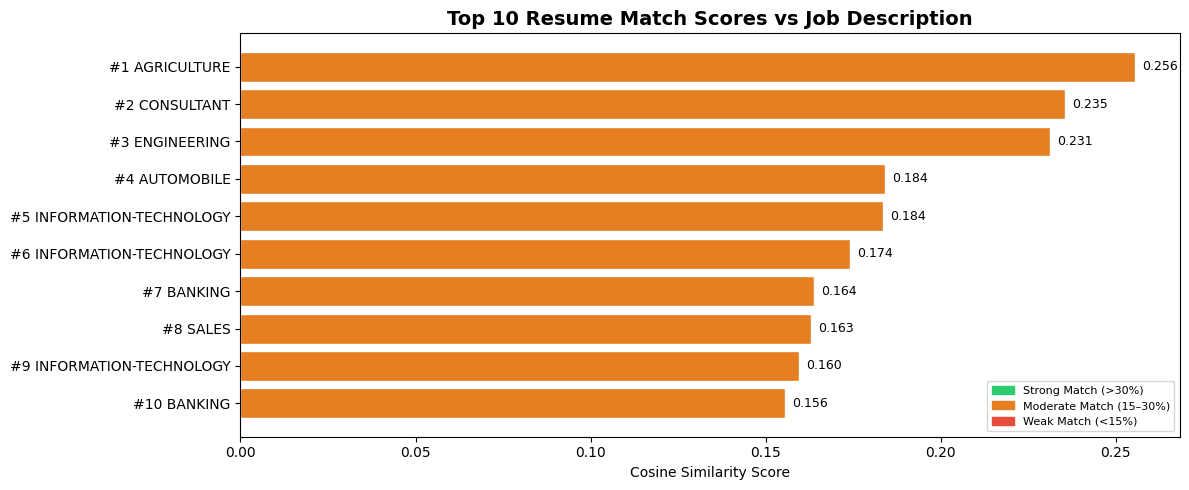

 Chart saved as match_scores.png


In [ ]:
plt.figure(figsize=(12, 5))

colors = ['#2ecc71' if s > 0.3 else '#e67e22' if s > 0.15 else '#e74c3c'
          for s in top_candidates['match_score']]

bars = plt.barh(
    [f"#{i+1} {row['Category']}" for i, row in top_candidates.iterrows()],
    top_candidates['match_score'],
    color=colors,
    edgecolor='white'
)

for bar, score in zip(bars, top_candidates['match_score']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#2ecc71', label='Strong Match (>30%)'),
    mpatches.Patch(color='#e67e22', label='Moderate Match (15–30%)'),
    mpatches.Patch(color='#e74c3c', label='Weak Match (<15%)')
]
plt.legend(handles=patches, loc='lower right', fontsize=8)

plt.title(f'Top {TOP_N} Resume Match Scores vs Job Description', fontsize=14, fontweight='bold')
plt.xlabel('Cosine Similarity Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('match_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart saved as match_scores.png')

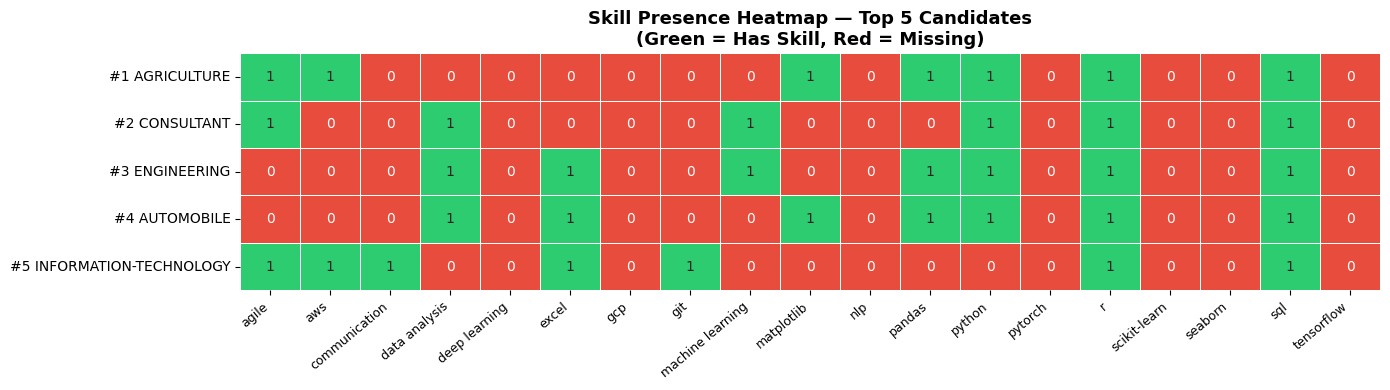

 Chart saved as skill_gap_heatmap.png


In [ ]:
top5 = top_candidates.head(5)

req_skills_sorted = sorted(required_skills)
heatmap_data = []

for _, row in top5.iterrows():
    heatmap_data.append([1 if skill in row['candidate_skills'] else 0
                         for skill in req_skills_sorted])

heatmap_df = pd.DataFrame(
    heatmap_data,
    index=[f"#{i+1} {row['Category']}" for i, row in top5.iterrows()],
    columns=req_skills_sorted
)

plt.figure(figsize=(14, 4))
sns.heatmap(
    heatmap_df,
    cmap=['#e74c3c', '#2ecc71'],
    linewidths=0.5,
    linecolor='white',
    annot=True,
    fmt='d',
    cbar=False
)
plt.title('Skill Presence Heatmap — Top 5 Candidates\n(Green = Has Skill, Red = Missing)', fontsize=13, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('skill_gap_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Chart saved as skill_gap_heatmap.png')

In [ ]:
print('Available categories:')
print(sorted(df['Category'].unique()))

Available categories:
['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [ ]:
FILTER_CATEGORY = 'Data Science'

if FILTER_CATEGORY:
    filtered = results[results['Category'] == FILTER_CATEGORY]
    filtered = filtered.sort_values('match_score', ascending=False).head(5).reset_index(drop=True)
    print(f'Top candidates in category: "{FILTER_CATEGORY}"')
else:
    filtered = top_candidates

for i, row in filtered.iterrows():
    print(f"\n#{i+1} Score: {row['match_score']:.4f}")
    print(f"   Has: {sorted(row['matching_skills'])}")
    print(f"   Missing: {sorted(row['skill_gap'])}")

Top candidates in category: "Data Science"


In [ ]:
export_df = results.sort_values('match_score', ascending=False)[[
    'candidate_id', 'Category', 'match_score', 'matching_skills', 'skill_gap'
]].copy()

export_df['matching_skills'] = export_df['matching_skills'].apply(lambda x: ', '.join(sorted(x)))
export_df['skill_gap'] = export_df['skill_gap'].apply(lambda x: ', '.join(sorted(x)))
export_df['match_score'] = export_df['match_score'].round(4)

output_path = 'resume_screening_results.csv'
export_df.to_csv(output_path, index=False)

files.download(output_path)
print(f'Results saved and downloaded: {output_path}')
export_df.head(10)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results saved and downloaded: resume_screening_results.csv


,candidate_id,Category,match_score,matching_skills,skill_gap
929,Candidate_930,AGRICULTURE,0.2556,"agile, aws, matplotlib, pandas, python, r, sql","communication, data analysis, deep learning, e..."
1218,Candidate_1219,CONSULTANT,0.2354,"agile, data analysis, machine learning, python...","aws, communication, deep learning, excel, gcp,..."
1762,Candidate_1763,ENGINEERING,0.2313,"data analysis, excel, machine learning, pandas...","agile, aws, communication, deep learning, gcp,..."
1339,Candidate_1340,AUTOMOBILE,0.1842,"data analysis, excel, matplotlib, pandas, pyth...","agile, aws, communication, deep learning, gcp,..."
297,Candidate_298,INFORMATION-TECHNOLOGY,0.1837,"agile, aws, communication, excel, git, r, sql","data analysis, deep learning, gcp, machine lea..."
331,Candidate_332,INFORMATION-TECHNOLOGY,0.1743,"aws, data analysis, excel, python, r, sql","agile, communication, deep learning, gcp, git,..."
2220,Candidate_2221,BANKING,0.1639,"agile, data analysis, r, sql","aws, communication, deep learning, excel, gcp,..."
1091,Candidate_1092,SALES,0.1629,"agile, communication, excel, r, sql","aws, data analysis, deep learning, gcp, git, m..."
298,Candidate_299,INFORMATION-TECHNOLOGY,0.1597,"aws, communication, python, r","agile, data analysis, deep learning, excel, gc..."
2199,Candidate_2200,BANKING,0.1555,"agile, aws, communication, deep learning, exce...","data analysis, gcp, machine learning, matplotl..."
